In [1]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

from config import CONFIG
from preprocess_external_test_data import load_and_prepare_external

2025-11-13 10:34:12.277688: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 10:34:13.149513: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# -------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------
CONFIG_EXT = CONFIG.copy()
CONFIG_EXT.update({
    "cell_line": "JUMP-Pilot-Data",
    "data_root": "./",
    "output_dir": "./JUMP-Pilot-Data/results",
    "aggregation": "mean",
    "normalization": "standard",
    "moa_condition": "merge_st_vs_tk",
    "metadata_file": "U2OS_JUMP_metadata_updated.xlsx"
})

print("✅ Config ready for Jump Pilot external evaluation.")

✅ Config ready for Jump Pilot external evaluation.


In [3]:
# -------------------------------------------------------
# STEP 1: Load and preprocess external dataset
# -------------------------------------------------------
data_ext = load_and_prepare_external(CONFIG_EXT)
df_ext = data_ext["df"]
df_ext = df_ext[df_ext["moa"].astype(str) != "0"]
df_ext = df_ext[df_ext["compound"].astype(str) != "DMSO"]

print(f"Preprocessing complete. Final shape: {df_ext.shape}")

Reading plate: P1_aligned.csv


/home/gauss/Documents/Project 2: Combining Molecular and Imagining Data for MOA Prediction/smile_image_global/Image-based Model/preprocess_external_test_data.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df.loc[:, ~df.columns.str.contains(r"(_X$|_Y$|_Z$)")]


Reading plate: P2_aligned.csv


/home/gauss/Documents/Project 2: Combining Molecular and Imagining Data for MOA Prediction/smile_image_global/Image-based Model/preprocess_external_test_data.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df.loc[:, ~df.columns.str.contains(r"(_X$|_Y$|_Z$)")]


Reading plate: P3_aligned.csv


/home/gauss/Documents/Project 2: Combining Molecular and Imagining Data for MOA Prediction/smile_image_global/Image-based Model/preprocess_external_test_data.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df.loc[:, ~df.columns.str.contains(r"(_X$|_Y$|_Z$)")]


Reading plate: P4_aligned.csv


/home/gauss/Documents/Project 2: Combining Molecular and Imagining Data for MOA Prediction/smile_image_global/Image-based Model/preprocess_external_test_data.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df.loc[:, ~df.columns.str.contains(r"(_X$|_Y$|_Z$)")]


✅ Reached end of Step 2
Before MOA condition: [0 nan 'CDK' 'AURORA KINASE' 'TUBULIN' 'TYROSINE KINASE' 'AKT' 'PARP'
 'HDAC' 'JAK' 'HMGCR']
After MOA condition: ['0' 'nan' 'SERINE/THREONINE PROTEIN KINASE' 'TUBULIN' 'TYROSINE KINASE'
 'PARP' 'HDAC' 'HMGCR']
Preprocessing complete. Final shape: (120, 2084)


In [4]:
# -------------------------------------------------------
# STEP 2: Load trained models (5 folds)
# -------------------------------------------------------
model_dir = "./results/models"
target_prefix = "U2OS_mean_standard_stratified_merge_st_vs_tk_fold"

model_files = [
    os.path.join(model_dir, f)
    for f in sorted(os.listdir(model_dir))
    if f.startswith(target_prefix) and f.endswith(".h5")
]

if len(model_files) != 5:
    raise ValueError(f"Expected 5 models, found {len(model_files)}")

print("\nFound the following U2OS models:")
for f in model_files:
    print("  -", os.path.basename(f))


Found the following U2OS models:
  - U2OS_mean_standard_stratified_merge_st_vs_tk_fold1.h5
  - U2OS_mean_standard_stratified_merge_st_vs_tk_fold2.h5
  - U2OS_mean_standard_stratified_merge_st_vs_tk_fold3.h5
  - U2OS_mean_standard_stratified_merge_st_vs_tk_fold4.h5
  - U2OS_mean_standard_stratified_merge_st_vs_tk_fold5.h5


In [5]:
# -------------------------------------------------------
# STEP 3: Build label mapping (keep original MOA untouched)
# -------------------------------------------------------
df_ext["moa"] = df_ext["moa"].astype(str)

unique_moas = sorted(df_ext["moa"].dropna().unique())
label_to_int = {moa: idx for idx, moa in enumerate(unique_moas)}
int_to_label = {v: k for k, v in label_to_int.items()}

# Create numeric array for evaluation, do NOT modify df_ext
y_ext = df_ext["moa"].map(label_to_int).values
print(f"\nBuilt label mapping for {len(label_to_int)} classes.")
print("Example mapping:", list(label_to_int.items()))


Built label mapping for 6 classes.
Example mapping: [('HDAC', 0), ('HMGCR', 1), ('PARP', 2), ('SERINE/THREONINE PROTEIN KINASE', 3), ('TUBULIN', 4), ('TYROSINE KINASE', 5)]


In [6]:
# -------------------------------------------------------
# STEP 4: Extract and normalize features
# -------------------------------------------------------
X_ext_full = df_ext[data_ext["feature_cols"]].copy()

if CONFIG_EXT["normalization"] == "standard":
    scaler = StandardScaler()
    X_ext_full = scaler.fit_transform(X_ext_full)
    X_ext_df = pd.DataFrame(X_ext_full, columns=data_ext["feature_cols"], index=df_ext.index)
else:
    X_ext_df = X_ext_full.copy()

print(f"External features prepared with shape: {X_ext_df.shape}")


✅ External features prepared with shape: (120, 2078)


In [7]:
# -------------------------------------------------------
# STEP 4.5: Verify external features vs fold features
# -------------------------------------------------------
features_dir = (
    "/home/gauss/Documents/Project 2: Combining Molecular and Imagining Data for MOA Prediction/"
    "smile_image_global/Image-based Model/fold_features"
)

for i, model_path in enumerate(model_files, start=1):
    print(f"\n🔹 Fold {i}: Checking feature alignment with {os.path.basename(model_path)}")

    # --- Load fold-specific feature list ---
    feat_path = os.path.join(
        features_dir,
        f"U2OS_mean_standard_stratified_merge_st_vs_tk_fold{i}_features.txt"
    )

    if not os.path.exists(feat_path):
        print(f"Missing feature file for fold {i}: {feat_path}")
        continue

    with open(feat_path, "r") as f:
        fold_features = [line.strip() for line in f if line.strip()]

    print(f"   ↳ Fold {i} feature count: {len(fold_features)}")
    print(f"   ↳ External dataset feature count: {X_ext_df.shape[1]}")

    # --- Check for missing and extra features ---
    fold_set = set(fold_features)
    external_set = set(X_ext_df.columns)

    missing_in_external = fold_set - external_set
    extra_in_external = external_set - fold_set

    print(f"   Missing in external: {len(missing_in_external)}")
    print(f"   Extra in external:   {len(extra_in_external)}")



🔹 Fold 1: Checking feature alignment with U2OS_mean_standard_stratified_merge_st_vs_tk_fold1.h5
   ↳ Fold 1 feature count: 300
   ↳ External dataset feature count: 2078
   Missing in external: 0
   Extra in external:   1778

🔹 Fold 2: Checking feature alignment with U2OS_mean_standard_stratified_merge_st_vs_tk_fold2.h5
   ↳ Fold 2 feature count: 300
   ↳ External dataset feature count: 2078
   Missing in external: 0
   Extra in external:   1778

🔹 Fold 3: Checking feature alignment with U2OS_mean_standard_stratified_merge_st_vs_tk_fold3.h5
   ↳ Fold 3 feature count: 300
   ↳ External dataset feature count: 2078
   Missing in external: 0
   Extra in external:   1778

🔹 Fold 4: Checking feature alignment with U2OS_mean_standard_stratified_merge_st_vs_tk_fold4.h5
   ↳ Fold 4 feature count: 300
   ↳ External dataset feature count: 2078
   Missing in external: 0
   Extra in external:   1778

🔹 Fold 5: Checking feature alignment with U2OS_mean_standard_stratified_merge_st_vs_tk_fold5.h5
   

In [8]:
# -------------------------------------------------------
# STEP 5: Predict for each fold using its own features
# -------------------------------------------------------
features_dir = (
    "/home/gauss/Documents/Project 2: Combining Molecular and Imagining Data for MOA Prediction/"
    "smile_image_global/Image-based Model/fold_features"
)

fold_probs = []

for i, model_path in enumerate(model_files, start=1):
    print(f"\n Fold {i}: Predicting with {os.path.basename(model_path)}")

    # --- Load fold-specific feature list ---
    feat_path = os.path.join(
        features_dir,
        f"U2OS_mean_standard_stratified_merge_st_vs_tk_fold{i}_features.txt"
    )
    with open(feat_path, "r") as f:
        fold_features = [line.strip() for line in f if line.strip()]

    print(f"   ↳ Fold {i} expects {len(fold_features)} features.")
    print(f"   ↳ External dataset has {X_ext_df.shape[1]} features.")

    # --- Check for missing features ---
    missing_features = [f for f in fold_features if f not in X_ext_df.columns]
    if missing_features:
        print(f"   Fold {i}: {len(missing_features)} missing features (e.g., {missing_features[:5]})")
    else:
        print(f"   All features for Fold {i} are present in external data.")

    # --- Align columns exactly as per fold feature order ---
    X_ext_fold_df = X_ext_df.reindex(columns=fold_features, fill_value=0)

    # --- Verify feature order alignment ---
    same_order = list(X_ext_fold_df.columns) == fold_features
    if same_order:
        print(f"   Fold {i}: Feature order matches exactly.")
    else:
        # Find a few mismatches for debugging
        mismatches = [
            (a, b)
            for a, b in zip(fold_features, X_ext_fold_df.columns)
            if a != b
        ]
        print(f"   Fold {i}: Feature order differs in {len(mismatches)} places (showing first 5):")
        print("      ", mismatches[:5])

    # --- Convert to numpy for model prediction ---
    X_ext_fold = X_ext_fold_df.values

    # --- Predict using this fold’s model ---
    model = load_model(model_path, compile=False)
    y_prob = model.predict(X_ext_fold, verbose=0)
    fold_probs.append(y_prob)

print(f"\n Completed predictions for all {len(fold_probs)} folds.")



 Fold 1: Predicting with U2OS_mean_standard_stratified_merge_st_vs_tk_fold1.h5
   ↳ Fold 1 expects 300 features.
   ↳ External dataset has 2078 features.
   All features for Fold 1 are present in external data.
   Fold 1: Feature order matches exactly.


2025-11-13 10:34:49.504877: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9612 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:17:00.0, compute capability: 7.5
2025-11-13 10:34:49.506378: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 9383 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:65:00.0, compute capability: 7.5
I0000 00:00:1763026490.736949  140051 service.cc:145] XLA service 0x740408008020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763026490.737003  140051 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
I0000 00:00:1763026490.737015  140051 service.cc:153]   StreamExecutor device (1): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2025-11-13 10:34:50.753798: I ten


 Fold 2: Predicting with U2OS_mean_standard_stratified_merge_st_vs_tk_fold2.h5
   ↳ Fold 2 expects 300 features.
   ↳ External dataset has 2078 features.
   All features for Fold 2 are present in external data.
   Fold 2: Feature order matches exactly.

 Fold 3: Predicting with U2OS_mean_standard_stratified_merge_st_vs_tk_fold3.h5
   ↳ Fold 3 expects 300 features.
   ↳ External dataset has 2078 features.
   All features for Fold 3 are present in external data.
   Fold 3: Feature order matches exactly.

 Fold 4: Predicting with U2OS_mean_standard_stratified_merge_st_vs_tk_fold4.h5
   ↳ Fold 4 expects 300 features.
   ↳ External dataset has 2078 features.
   All features for Fold 4 are present in external data.
   Fold 4: Feature order matches exactly.

 Fold 5: Predicting with U2OS_mean_standard_stratified_merge_st_vs_tk_fold5.h5
   ↳ Fold 5 expects 300 features.
   ↳ External dataset has 2078 features.
   All features for Fold 5 are present in external data.
   Fold 5: Feature order m

In [9]:
# -------------------------------------------------------
# STEP 6: Aggregate predictions and decode labels
# -------------------------------------------------------
y_prob_mean = np.mean(fold_probs, axis=0)
y_pred_mean = np.argmax(y_prob_mean, axis=1)

# Known classes (adjust to match your training set)
known_classes = [
    "HMGCR", "HDAC", "PARP", "TUBULIN",
    "TYROSINE KINASE", "SERINE/THREONINE PROTEIN KINASE"
]

# Decode with fallback to "Other"
y_pred_labels = [
    int_to_label.get(i, "Other") if int_to_label.get(i) in known_classes else "Other"
    for i in y_pred_mean
]

# Debug info
print(f"\n✅ Aggregated predictions from {len(fold_probs)} folds.")
print(f"Output shape: {y_prob_mean.shape}")
print("Unique predicted labels:", np.unique(y_pred_labels))
print("Known classes:", known_classes)



✅ Aggregated predictions from 5 folds.
Output shape: (120, 7)
Unique predicted labels: ['HDAC' 'Other' 'PARP' 'SERINE/THREONINE PROTEIN KINASE' 'TUBULIN'
 'TYROSINE KINASE']
Known classes: ['HMGCR', 'HDAC', 'PARP', 'TUBULIN', 'TYROSINE KINASE', 'SERINE/THREONINE PROTEIN KINASE']


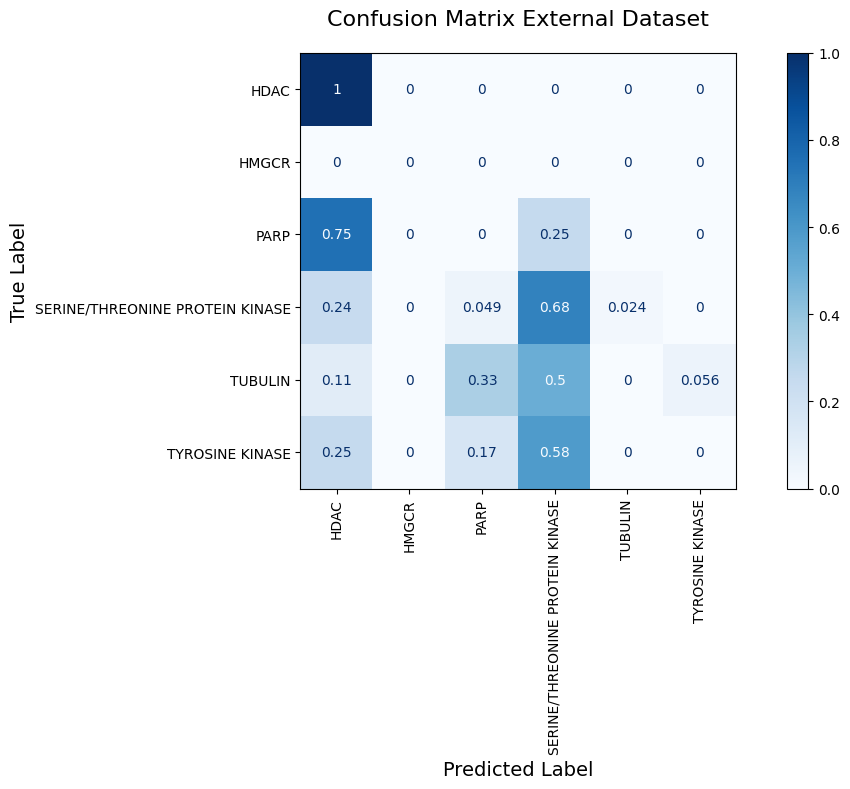

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Filter out UNKNOWN predictions (if any) ---
valid_mask = ~pd.Series(y_pred_labels).str.startswith("UNKNOWN")
true_valid = df_ext["moa"].values[valid_mask]
pred_valid = np.array(y_pred_labels)[valid_mask]

# --- Compute normalized confusion matrix ---
labels_sorted = sorted(set(true_valid))
cm_norm = confusion_matrix(true_valid, pred_valid, normalize="true", labels=labels_sorted)

# --- Proper large figure setup ---
fig, ax = plt.subplots(figsize=(12, 8))  # 👈 This one actually controls the size
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels_sorted)
disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    colorbar=True,
    ax=ax  # 👈 attach the plot to your big figure
)

# --- Customize titles and labels ---
ax.set_title("Confusion Matrix External Dataset", fontsize=16, pad=20)
ax.set_xlabel("Predicted Label", fontsize=14)
ax.set_ylabel("True Label", fontsize=14)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.show()


In [16]:
df_ext["moa"].value_counts()

moa
SERINE/THREONINE PROTEIN KINASE    56
TUBULIN                            20
TYROSINE KINASE                    20
HDAC                               12
PARP                                8
HMGCR                               4
Name: count, dtype: int64